# 01 -- Pozyskanie danych: Dane hydrologiczne IMGW

Ten notebook obejmuje pierwsze kroki w analizie danych hydrologicznych:

1. **Przegladanie dostepnych stacji wodowskazowych IMGW** -- znajdowanie ID stacji
2. **Pobieranie historycznych danych dobowych** -- z publicznego archiwum IMGW
3. **Parsowanie i walidacja** -- obsluga dwoch er formatu CSV
4. **Pierwszy rzut oka na dane** -- podstawowe wykresy i podsumowanie

**Zrodlo danych:** [IMGW Dane Publiczne](https://danepubliczne.imgw.pl/data/dane_pomiarowo_obserwacyjne/dane_hydrologiczne/dobowe/)

---

## Konfiguracja

**Prompt do LLM:**
> *"Napisz kod konfiguracji notebooka Jupyter: załaduj biblioteki pandas, numpy, plotly oraz modul src/imgw_data. Ustaw opcje wyswietlania pandas."*

**Użyte moduły/funkcje:** `src.imgw_data`: get_station_list, get_current_hydro, download_daily_data, save_processed, load_processed

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.imgw_data import (
    get_station_list,
    get_current_hydro,
    download_daily_data,
    save_processed,
    load_processed,
)

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
print('Moduły załadowane.')

Moduły załadowane.


### Moduł `src/imgw_data.py` — pobieranie i parsowanie danych IMGW

**Prompt do LLM tworzący ten moduł:**
> *"Napisz modul Pythona src/imgw_data.py do pobierania danych hydrologicznych z archiwum IMGW
> (https://danepubliczne.imgw.pl/data/dane_pomiarowo_obserwacyjne/dane_hydrologiczne/dobowe/).
> Moduł powinien:
> 1. Pobierać listę stacji z pliku CSV i umożliwiać wyszukiwanie po nazwie/rzece/ID.
> 2. Pobierać aktualne odczyty z REST API (https://danepubliczne.imgw.pl/api/data/hydro).
> 3. Pobierać historyczne dane dobowe jako pliki ZIP, cache'ować je lokalnie.
> 4. Parsować CSV z dwóch formatow: przed 2023 (CP-1250, przecinek, cudzyslow) i 2023+ (UTF-8, srednik).
> 5. Automatycznie wykrywać kodowanie i separator.
> 6. Zastępować wartości strażnikowe IMGW (9999, 99999) na NaN.
> 7. Dodawać kolumnę z datą kalendarzową (rok hydrologiczny zaczyna sie w listopadzie!).
> 8. Zapisywać/wczytywać przetworzone dane jako Parquet.
> Kolumny wynikowe: station_id, station_name, river_name, water_level_cm, discharge_m3s, date."*

**Wynik:** Moduł `src/imgw_data.py` z funkcjami:
- `get_station_list()` — lista wszystkich stacji IMGW
- `search_stations(query, by)` — wyszukiwanie stacji
- `get_current_hydro()` — bieżące odczyty z API
- `download_daily_data(station_ids, year_from, year_to)` — pobieranie + parsowanie
- `save_processed(df, path)` / `load_processed(path)` — zapis/odczyt Parquet

---
## Krok 1: Przeglądanie stacji wodowskazowych IMGW

IMGW prowadzi listę wszystkich stacji hydrologicznych. Każda stacja ma **9-cyfrowy identyfikator**, nazwę i jest przypisana do rzeki.

Możemy również użyć **API na żywo**, aby uzyskać aktualne odczyty wraz ze współrzędnymi (szerokość/długość geograficzna) — przydatne do szukania stacji w interesujacym nas regionie.

<details>
<summary>1a. Lista stacji (z archiwum) (kliknij aby rozwinac)</summary>

### 1a. Lista stacji (z archiwum)

**Prompt do LLM:**
> *"Napisz kod ktory użyje funkcji get_station_list() z modułu src/imgw_data, pobierze listę stacji IMGW i wyświetli pierwsze 10 wierszy."*

**Użyte moduły/funkcje:** `src.imgw_data.get_station_list()` — pobiera CSV z lista stacji z archiwum IMGW

```python
# Pobierz pełną listę stacji
stations = get_station_list()
print(f'Łączna liczba stacji: {len(stations)}')
stations.head(20)
```

</details>

<details>
<summary> (kliknij aby rozwinac)</summary>

**Prompt do LLM:**
> *"Napisz kod ktory przefiltruje DataFrame stacji IMGW po nazwie rzeki (zmienna river_name). Filtrowanie case-insensitive, pokaż wszystkie pasujące stacje."*

**Użyte moduły/funkcje:** `pandas.str.contains()` — filtrowanie tekstowe w DataFrame

```python
# Wyszukaj stacje po nazwie rzeki (przykład: Dunajec)
river_name = 'Dunajec'  # <-- ZMIEŃ na interesującą Cię rzekę

mask = stations['river'].str.contains(river_name, case=False, na=False)
stations_on_river = stations[mask]
print(f'Stacje na rzece {river_name}: {len(stations_on_river)}')
stations_on_river
```

</details>

<details>
<summary>1b. Aktualne odczyty ze współrzędnymi (z API na żywo) (kliknij aby rozwinac)</summary>

### 1b. Aktualne odczyty ze współrzędnymi (z API na żywo)

API na żywo daje nam współrzędne stacji — przydatne do wizualizacji na mapie. Uwaga: zwraca **tylko bieżące** odczyty, nie dane historyczne.

**Prompt do LLM:**
> *"Napisz kod ktory użyje funkcji get_current_hydro() z modułu src/imgw_data, pobierze bieżące dane ze wszystkich stacji i wyświetli kolumny: id, nazwa, rzeka, wojewodztwo, lat, lon."*

**Użyte moduły/funkcje:** `src.imgw_data.get_current_hydro()` — REST API IMGW zwraca JSON z biezacymi danymi

```python
# Pobierz aktualne dane hydrologiczne (ze współrzędnymi)
current = get_current_hydro()
print(f'Aktywne stacje: {len(current)}')
print(current)
current[['id_stacji', 'stacja', 'rzeka', 'wojewodztwo', 'lat', 'lon', 'stan_wody', 'przelyw']].head(10)
```

</details>

<details>
<summary> (kliknij aby rozwinac)</summary>

**Prompt do LLM:**
> *"Napisz kod ktory użyje plotly scatter_mapbox do stworzenia interaktywnej mapy stacji IMGW na tle OpenStreetMap. Dane z DataFrame current — kolumny lat, lon, stacja, rzeka. Koloruj po rzece, dodaj hover z przeplywem."*

**Użyte moduły/funkcje:** `plotly.express.scatter_mapbox()` — mapa z punktami na tle OSM

```python
# Mapa wszystkich stacji (interaktywna — przybliż do swojego obszaru)
current['lat'] = pd.to_numeric(current['lat'], errors='coerce')
current['lon'] = pd.to_numeric(current['lon'], errors='coerce')
current_valid = current.dropna(subset=['lat', 'lon'])

fig = px.scatter_mapbox(
    current_valid,
    lat='lat', lon='lon',
    hover_name='stacja',
    hover_data=['id_stacji', 'rzeka', 'stan_wody', 'przelyw'],
    color='rzeka',
    zoom=5,
    height=600,
    title='Stacje hydrologiczne IMGW'
)
fig.update_layout(mapbox_style='open-street-map', showlegend=False)
fig.show()
```

</details>

### 1c. Wybór stacji

Wpisz identyfikatory stacji do analizy poniżej. Możesz wybrać:
- **Stację główną** — glowna stacje do analizy
- **Stację/stacje referencyjne** — w pobliżu na tej samej rzece, do uzupełniania luk i walidacji krzyżowej

**Prompt do LLM:**
> *"Napisz kod definiujacy zmienne konfiguracyjne: listę ID stacji IMGW (STATION_IDS), początkowy i końcowy rok hydrologiczny. Dodaj komentarze dla uzytkownika."*

**Użyte moduły/funkcje:** Konfiguracja uzytkownika — te wartosci sa uzywane przez `download_daily_data()`

In [2]:
# ============================================================
# DANE WEJŚCIOWE: Wpisz identyfikatory swoich stacji
# ============================================================
STATION_IDS = [
    '151160150',  # Malczyce, Odra
    '151160170'
]

YEAR_FROM = 1981   # Początkowy rok hydrologiczny
YEAR_TO   = 2024   # Końcowy rok hydrologiczny
# ============================================================

print(f'Wybrane stacje: {STATION_IDS}')
print(f'Okres: {YEAR_FROM}–{YEAR_TO} ({YEAR_TO - YEAR_FROM + 1} lat)')

Wybrane stacje: ['151160150', '151160170']
Okres: 1981–2024 (44 lat)


---
## Krok 2: Pobieranie danych historycznych

Dane są pobierane z publicznego archiwum IMGW jako pliki ZIP. Każdy plik zawiera dane CSV za jeden rok hydrologiczny (lub miesiąc, dla danych sprzed 2023).

**To uruchamia się raz** — pliki są zapisywane w `data/raw/`. Ponowne uruchomienie pomija już pobrane pliki.

⚠️ Uwaga: Pobieranie wielu lat może potrwać kilka minut.

**Prompt do LLM:**
> *"Napisz kod ktory użyje funkcji download_daily_data() z modułu src/imgw_data do pobrania danych dobowych dla stacji z STATION_IDS za lata YEAR_FROM-YEAR_TO. Zapisz do ../data/raw. Pokaż liczbę wierszy, zakres dat i znalezione stacje."*

**Użyte moduły/funkcje:** `src.imgw_data.download_daily_data()` — pobiera ZIP z IMGW, parsuje CSV, obsluguje 2 formaty (CP1250/comma i UTF8/semicolon)

In [3]:
# Pobierz dane (z cache — bezpieczne do ponownego uruchomienia)
df = download_daily_data(
    station_ids=STATION_IDS,
    year_from=YEAR_FROM,
    year_to=YEAR_TO,
    data_dir='../data/raw',
)

print(f'\nŁączna liczba wierszy: {len(df)}')
print(f'Zakres dat: {df["date"].min()} — {df["date"].max()}')
print(f'Znalezione stacje: {df["station_id"].unique().tolist()}')
df.head()

  Using cached codz_1981_01.zip
  Using cached codz_1981_02.zip
  Using cached codz_1981_03.zip
  Using cached codz_1981_04.zip
  Using cached codz_1981_05.zip
  Using cached codz_1981_06.zip
  Using cached codz_1981_07.zip
  Using cached codz_1981_08.zip
  Using cached codz_1981_09.zip
  Using cached codz_1981_10.zip
  Using cached codz_1981_11.zip
  Using cached codz_1981_12.zip
  Using cached codz_1982_01.zip
  Using cached codz_1982_02.zip
  Using cached codz_1982_03.zip
  Using cached codz_1982_04.zip
  Using cached codz_1982_05.zip
  Using cached codz_1982_06.zip
  Using cached codz_1982_07.zip
  Using cached codz_1982_08.zip
  Using cached codz_1982_09.zip
  Using cached codz_1982_10.zip
  Using cached codz_1982_11.zip
  Using cached codz_1982_12.zip
  Using cached codz_1983_01.zip
  Using cached codz_1983_02.zip
  Using cached codz_1983_03.zip
  Using cached codz_1983_04.zip
  Using cached codz_1983_05.zip
  Using cached codz_1983_06.zip
  Using cached codz_1983_07.zip
  Using 

,station_id,station_name,river_name,water_level_cm,discharge_m3s,date
0,151160150,MALCZYCE,Odra (1),110.0,136.0,1980-11-01
1,151160150,MALCZYCE,Odra (1),110.0,136.0,1980-11-02
2,151160150,MALCZYCE,Odra (1),112.0,138.0,1980-11-03
3,151160150,MALCZYCE,Odra (1),112.0,138.0,1980-11-04
4,151160150,MALCZYCE,Odra (1),112.0,138.0,1980-11-05


**Prompt do LLM:**
> *"Napisz kod ktory użyje funkcji save_processed() z modułu src/imgw_data do zapisania DataFrame df jako plik Parquet w ../data/processed/."*

**Użyte moduły/funkcje:** `src.imgw_data.save_processed()` — zapis do Parquet (zachowuje typy danych, kompresja)

In [4]:
# Zapisz przetworzone dane do wykorzystania w kolejnych notebookach
save_processed(df, '../data/processed/daily_hydro.parquet')

Saved 31410 rows to ../data/processed/daily_hydro.parquet


---
## Krok 3: Przegląd danych

Sprawdźmy co mamy: podstawowe statystyki, typy danych i pierwszy wykres.

**Prompt do LLM:**
> *"Napisz kod ktory wyświetli podstawowe informacje o DataFrame df: typy danych (dtypes), wymiary (shape) i liczbę brakujących wartości w każdej kolumnie."*

**Użyte moduły/funkcje:** `pandas.DataFrame.dtypes`, `.shape`, `.isnull().sum()`

In [5]:
# Podstawowe informacje
print('Typy danych:')
print(df.dtypes)
print(f'\nWymiary: {df.shape}')
print(f'\nBrakujące wartości:')
print(df.isnull().sum())

Typy danych:
station_id                   str
station_name                 str
river_name                   str
water_level_cm           float64
discharge_m3s            float64
date              datetime64[us]
dtype: object

Wymiary: (31410, 6)

Brakujące wartości:
station_id            0
station_name          0
river_name            0
water_level_cm        0
discharge_m3s     14609
date                  0
dtype: int64


**Prompt do LLM:**
> *"Napisz kod ktory w pętli po unikalnych station_id wyświetli nazwę stacji i statystyki describe() dla kolumn water_level_cm i discharge_m3s."*

**Użyte moduły/funkcje:** `pandas.DataFrame.describe()` — min, max, mean, std, percentyle

In [6]:
# Statystyki podsumowujące dla każdej stacji
for sid in df['station_id'].unique():
    sdf = df[df['station_id'] == sid]
    name = sdf['station_name'].iloc[0]
    river = sdf['river_name'].iloc[0]
    print(f'\n--- Stacja {sid}: {name} ({river}) ---')
    print(sdf[['water_level_cm', 'discharge_m3s']].describe().round(2))


--- Stacja 151160150: MALCZYCE (Odra (1)) ---
       water_level_cm  discharge_m3s
count        15705.00       15705.00
mean           166.36         143.09
std            101.35         120.18
min             -8.00          22.80
25%             95.00          79.30
50%            148.00         115.00
75%            208.00         164.00
max            796.00        3020.00

--- Stacja 151160170: BRZEG DOLNY (Odra (1)) ---
       water_level_cm  discharge_m3s
count        15705.00        1096.00
mean           191.72         195.88
std            110.17         177.08
min             20.00          53.00
25%            113.00         105.00
50%            170.00         147.00
75%            250.00         222.00
max            962.00        2040.00


### Szereg czasowy przepływu

**Prompt do LLM:**
> *"Napisz kod ktory użyje plotly express line() do narysowania szeregu czasowego przeplywu dobowego. Os X: date, os Y: discharge_m3s, kolor: station_name. Dodaj hovermode x unified."*

**Użyte moduły/funkcje:** `plotly.express.line()` — interaktywny wykres liniowy

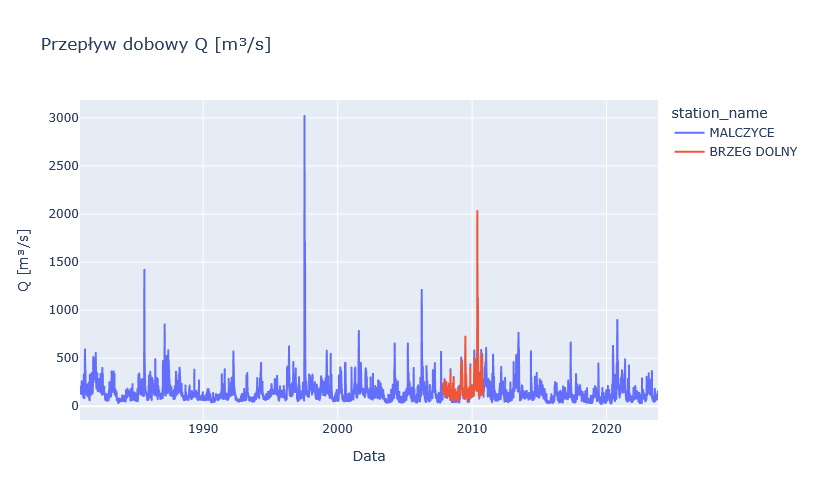

In [7]:
# Wykres szeregu czasowego przepływu dla wszystkich stacji
fig = px.line(
    df, x='date', y='discharge_m3s',
    color='station_name',
    title='Przepływ dobowy Q [m³/s]',
    labels={'discharge_m3s': 'Q [m³/s]', 'date': 'Data'},
    height=500,
)
fig.update_layout(hovermode='x unified')
fig.show()

### Szereg czasowy stanów wody

**Prompt do LLM:**
> *"Napisz analogiczny kod jak powyzej, ale dla kolumny water_level_cm (stan wody w cm)."*

**Użyte moduły/funkcje:** `plotly.express.line()` — analogicznie jak dla przeplywu

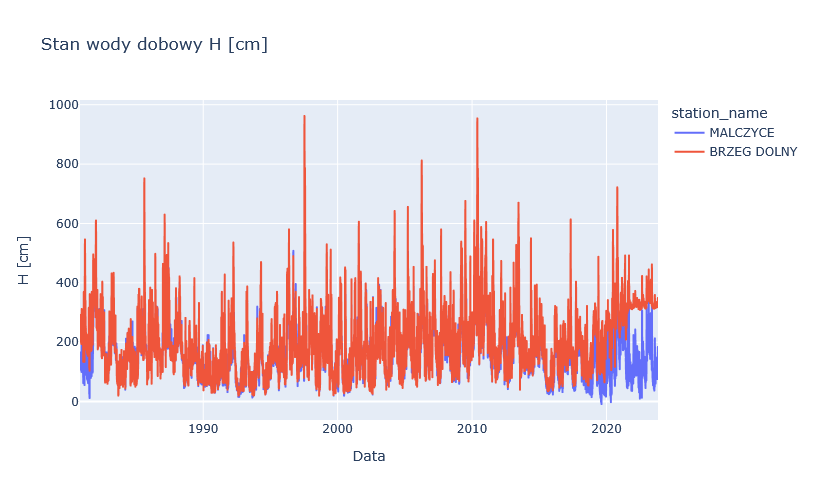

In [8]:
fig = px.line(
    df, x='date', y='water_level_cm',
    color='station_name',
    title='Stan wody dobowy H [cm]',
    labels={'water_level_cm': 'H [cm]', 'date': 'Data'},
    height=500,
)
fig.update_layout(hovermode='x unified')
fig.show()

---
## Podsumowanie

W tym notebooku:
1. Przegladnelismy dostepne stacje IMGW i wybralismy nasze wodowskazy
2. Pobralismy historyczne dane dobowe z archiwum IMGW
3. Sparsowalismy zarowno stary (CP1250/przecinek) jak i nowy (UTF8/srednik) format
4. Przejrzelismy podstawowe statystyki i wykresy przeplywu i stanow wody

**Dalej:** `02_data_quality.ipynb` -- kontrola jakosci, uzupelnianie luk (krzywa konsumcyjna + korelacja stacji), identyfikacja lat do usuniecia

Dane zapisane w: `data/processed/daily_hydro.parquet`